#### Retail Demand Forecasting with PySpark + XGBoost

In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, to_date, sum as Fsum, avg, max as Fmax, min as Fmin,
    year, month, dayofweek, weekofyear, when, first
)
from pyspark.sql.window import Window
from pyspark.sql.functions import lag

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

/opt/homebrew/Caskroom/miniforge/base/envs/DistributedComputing/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


#### Start Spark

In [2]:
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("retail-forecast")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("WARN")

print("Spark version:", spark.version)

26/03/23 17:19:45 WARN Utils: Your hostname, MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 10.0.0.180 instead (on interface en0)
26/03/23 17:19:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/23 17:19:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/23 17:19:46 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/23 17:19:46 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
Spark version: 3.3.1


#### Load raw data

In [4]:
DATA_PATH = "../data/data_xyz_foods.csv"   # change this path if needed

df = spark.read.csv(DATA_PATH, header=True, inferSchema=True)

print(df.columns)
df.show(5, truncate=False)
print("Rows:", df.count())

['Date', 'ProductID', 'StoreID', 'ProductName', 'Quantity', 'Price']
+-------------------+------------+------------+-----------------------------------+--------+------------------+
|Date               |ProductID   |StoreID     |ProductName                        |Quantity|Price             |
+-------------------+------------+------------+-----------------------------------+--------+------------------+
|2025-08-04 00:00:00|16a562fb5931|14bce06b5959|Pasta and Beans and Tandoori Masala|1.45    |4.8999999999999995|
|2025-08-26 00:00:00|16a562fb5931|b3815c950a50|Pasta and Beans and Tandoori Masala|1.45    |4.8999999999999995|
|2024-12-20 00:00:00|16a562fb5931|53fff28459d3|Pasta and Beans and Tandoori Masala|2.0     |7.0               |
|2025-04-08 00:00:00|2ab97e780325|8268a65fda4b|Pork belly buns and BBQ Seasoning  |1.0     |7.0               |
|2025-04-23 00:00:00|2ab97e780325|024a0bfc4484|Pork belly buns and BBQ Seasoning  |1.0     |7.0               |
+-------------------+------------+-

In [5]:
df = (
    df
    .withColumn("Date", to_date(col("Date")))
    .withColumn("Quantity", col("Quantity").cast("double"))
    .withColumn("Price", col("Price").cast("double"))
    .select("StoreID", "ProductID", "Date", "ProductName", "Quantity", "Price")
)

df.printSchema()
df.show(5, truncate=False)

root
 |-- StoreID: string (nullable = true)
 |-- ProductID: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- ProductName: string (nullable = true)
 |-- Quantity: double (nullable = true)
 |-- Price: double (nullable = true)

+------------+------------+----------+-----------------------------------+--------+------------------+
|StoreID     |ProductID   |Date      |ProductName                        |Quantity|Price             |
+------------+------------+----------+-----------------------------------+--------+------------------+
|14bce06b5959|16a562fb5931|2025-08-04|Pasta and Beans and Tandoori Masala|1.45    |4.8999999999999995|
|b3815c950a50|16a562fb5931|2025-08-26|Pasta and Beans and Tandoori Masala|1.45    |4.8999999999999995|
|53fff28459d3|16a562fb5931|2024-12-20|Pasta and Beans and Tandoori Masala|2.0     |7.0               |
|8268a65fda4b|2ab97e780325|2025-04-08|Pork belly buns and BBQ Seasoning  |1.0     |7.0               |
|024a0bfc4484|2ab97e780325|2025-04-23|P

In [6]:
df.toPandas().isna().sum()

StoreID        0
ProductID      0
Date           0
ProductName    0
Quantity       0
Price          0
dtype: int64

#### Aggregate to daily StoreID + ProductID level

In [7]:
daily_df = (
    df.groupBy("StoreID", "ProductID", "Date")
      .agg(
          first("ProductName").alias("ProductName"),
          Fsum("Quantity").alias("Quantity"),
          avg("Price").alias("avg_price"),
          Fmax("Price").alias("max_price"),
          Fmin("Price").alias("min_price")
      )
)

daily_df.show(10, truncate=False)

+------------+------------+----------+-----------------------------------+--------+------------------+---------+------------------+
|StoreID     |ProductID   |Date      |ProductName                        |Quantity|avg_price         |max_price|min_price         |
+------------+------------+----------+-----------------------------------+--------+------------------+---------+------------------+
|024a0bfc4484|16a562fb5931|2024-10-08|Pasta and Beans and Tandoori Masala|51.0    |7.0476190476190474|8.0      |7.0               |
|024a0bfc4484|16a562fb5931|2024-10-09|Pasta and Beans and Tandoori Masala|62.0    |7.125             |8.0      |7.0               |
|024a0bfc4484|16a562fb5931|2024-10-24|Pasta and Beans and Tandoori Masala|91.0    |7.056338028169014 |8.0      |7.0               |
|024a0bfc4484|16a562fb5931|2024-12-04|Pasta and Beans and Tandoori Masala|59.0    |7.153846153846154 |8.0      |7.0               |
|024a0bfc4484|16a562fb5931|2024-12-31|Pasta and Beans and Tandoori Masala|47

#### Add calendar features

In [8]:
features_df = (
    daily_df
    .withColumn("year", year("Date"))
    .withColumn("month", month("Date"))
    .withColumn("day_of_week", dayofweek("Date"))
    .withColumn("week_of_year", weekofyear("Date"))
    .withColumn("is_weekend", when(dayofweek("Date").isin([1, 7]), 1).otherwise(0))
)

#### Add lag features

In [9]:
w = Window.partitionBy("StoreID", "ProductID").orderBy("Date")

features_df = (
    features_df
    .withColumn("lag_1", lag("Quantity", 1).over(w))
    .withColumn("lag_7", lag("Quantity", 7).over(w))
    .withColumn("lag_14", lag("Quantity", 14).over(w))
    .withColumn("lag_28", lag("Quantity", 28).over(w))
)

### Fill Spark nulls

In [10]:
features_df = features_df.fillna({
    "lag_1": 0,
    "lag_7": 0,
    "lag_14": 0,
    "lag_28": 0,
    "avg_price": 0,
    "max_price": 0,
    "min_price": 0
})

#### Convert to pandas for modeling

In [11]:
model_df = features_df.toPandas()
model_df["Date"] = pd.to_datetime(model_df["Date"])
model_df = model_df.sort_values(["StoreID", "ProductID", "Date"]).reset_index(drop=True)

model_df.head()

,StoreID,ProductID,Date,ProductName,Quantity,avg_price,max_price,min_price,year,month,day_of_week,week_of_year,is_weekend,lag_1,lag_7,lag_14,lag_28
0,024a0bfc4484,16a562fb5931,2024-09-15,Pasta and Beans and Tandoori Masala,9.0,7.0,7.0,7.0,2024,9,1,37,1,0.0,0.0,0.0,0.0
1,024a0bfc4484,16a562fb5931,2024-09-16,Pasta and Beans and Tandoori Masala,31.0,7.0,7.0,7.0,2024,9,2,38,0,9.0,0.0,0.0,0.0
2,024a0bfc4484,16a562fb5931,2024-09-17,Pasta and Beans and Tandoori Masala,38.0,7.0,7.0,7.0,2024,9,3,38,0,31.0,0.0,0.0,0.0
3,024a0bfc4484,16a562fb5931,2024-09-18,Pasta and Beans and Tandoori Masala,31.0,7.0,7.0,7.0,2024,9,4,38,0,38.0,0.0,0.0,0.0
4,024a0bfc4484,16a562fb5931,2024-09-19,Pasta and Beans and Tandoori Masala,36.0,6.5,7.0,6.0,2024,9,5,38,0,31.0,0.0,0.0,0.0


#### Add Rolling Features

In [12]:
model_df["rolling_mean_7"] = (
    model_df.groupby(["StoreID", "ProductID"])["Quantity"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

model_df["rolling_mean_28"] = (
    model_df.groupby(["StoreID", "ProductID"])["Quantity"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

model_df["rolling_std_7"] = (
    model_df.groupby(["StoreID", "ProductID"])["Quantity"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

model_df["rolling_std_28"] = (
    model_df.groupby(["StoreID", "ProductID"])["Quantity"]
    .transform(lambda x: x.shift(1).rolling(28).std())
)

#### Add price change features

In [13]:
model_df["price_change_1"] = (
    model_df.groupby(["StoreID", "ProductID"])["avg_price"]
    .transform(lambda x: x.pct_change().fillna(0))
)

model_df["price_change_7"] = (
    model_df.groupby(["StoreID", "ProductID"])["avg_price"]
    .transform(lambda x: x.pct_change(7).fillna(0))
)

model_df["price_change_28"] = (
    model_df.groupby(["StoreID", "ProductID"])["avg_price"]
    .transform(lambda x: x.pct_change(28).fillna(0))
)

#### Add store/product context features

In [14]:
model_df["store_total"] = (
    model_df.groupby(["StoreID", "Date"])["Quantity"]
    .transform("sum")
)

model_df["product_total"] = (
    model_df.groupby(["ProductID", "Date"])["Quantity"]
    .transform("sum")
)

model_df["store_rolling_7"] = (
    model_df.groupby("StoreID")["store_total"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

model_df["product_rolling_7"] = (
    model_df.groupby("ProductID")["product_total"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

#### Add momentum features

In [15]:
model_df["momentum_7"] = model_df["lag_1"] - model_df["lag_7"]
model_df["momentum_28"] = model_df["lag_1"] - model_df["lag_28"]

#### Final fillna

In [16]:
model_df = model_df.fillna(0)

#### Encode categorical IDs

In [17]:
store_encoder = LabelEncoder()
product_encoder = LabelEncoder()

model_df["StoreID_enc"] = store_encoder.fit_transform(model_df["StoreID"].astype(str))
model_df["ProductID_enc"] = product_encoder.fit_transform(model_df["ProductID"].astype(str))

#### Time-based split

In [18]:
cutoff_date = model_df["Date"].quantile(0.8)

train_pd = model_df[model_df["Date"] < cutoff_date].copy()
test_pd = model_df[model_df["Date"] >= cutoff_date].copy()

print("Cutoff date:", cutoff_date)
print("Train rows:", len(train_pd))
print("Test rows:", len(test_pd))
print("Train date range:", train_pd["Date"].min(), "to", train_pd["Date"].max())
print("Test date range:", test_pd["Date"].min(), "to", test_pd["Date"].max())

Cutoff date: 2025-10-06 00:00:00
Train rows: 44495
Test rows: 11189
Train date range: 2024-08-01 00:00:00 to 2025-10-05 00:00:00
Test date range: 2025-10-06 00:00:00 to 2025-12-31 00:00:00


#### Log-transform target

In [19]:
train_pd["log_quantity"] = np.log1p(train_pd["Quantity"])
test_pd["log_quantity"] = np.log1p(test_pd["Quantity"])

#### Define feature list

In [20]:
ml_features = [
    "StoreID_enc",
    "ProductID_enc",
    "year",
    "month",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "avg_price",
    "max_price",
    "min_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28",
    "price_change_1",
    "price_change_7",
    "price_change_28",
    "store_total",
    "product_total",
    "store_rolling_7",
    "product_rolling_7",
    "momentum_7",
    "momentum_28",
]

#### Build train/test matrices

In [21]:
X_train = train_pd[ml_features].apply(pd.to_numeric, errors="coerce").fillna(0)
X_test = test_pd[ml_features].apply(pd.to_numeric, errors="coerce").fillna(0)

y_train = pd.to_numeric(train_pd["log_quantity"], errors="coerce").fillna(0)
y_test = pd.to_numeric(test_pd["Quantity"], errors="coerce").fillna(0)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (44495, 27)
X_test: (11189, 27)


#### Train XGBoost

In [22]:
model = XGBRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

#### Predict

In [23]:
preds_log = model.predict(X_test)
preds = np.expm1(preds_log)
preds = np.maximum(preds, 0)

#### Evaluate model

In [24]:
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
wape = np.sum(np.abs(y_test - preds)) / np.sum(np.abs(y_test))

print("MAE:", mae)
print("RMSE:", rmse)
print("WAPE:", wape)

MAE: 13.895082005845902
RMSE: 68.64250153950023
WAPE: 0.14303292792091185


#### Sanity checks

In [25]:
print("Actual mean:", y_test.mean())
print("Predicted mean:", preds.mean())

Actual mean: 97.14603628563768
Predicted mean: 94.46385


In [26]:
comparison = test_pd[["StoreID", "ProductID", "ProductName", "Date", "Quantity"]].copy()
comparison["PredictedQuantity"] = preds
comparison.head(20)

,StoreID,ProductID,ProductName,Date,Quantity,PredictedQuantity
384,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-06,87.0,86.075821
385,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-07,100.0,102.649208
386,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-08,92.0,91.912766
387,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-09,144.0,141.286255
388,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-10,91.0,94.771118
389,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-11,74.0,75.606552
390,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-12,79.0,76.181213
391,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-13,76.0,77.665062
392,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-14,114.0,117.189728
393,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2025-10-15,106.0,111.187965


#### Plot actual vs predicted

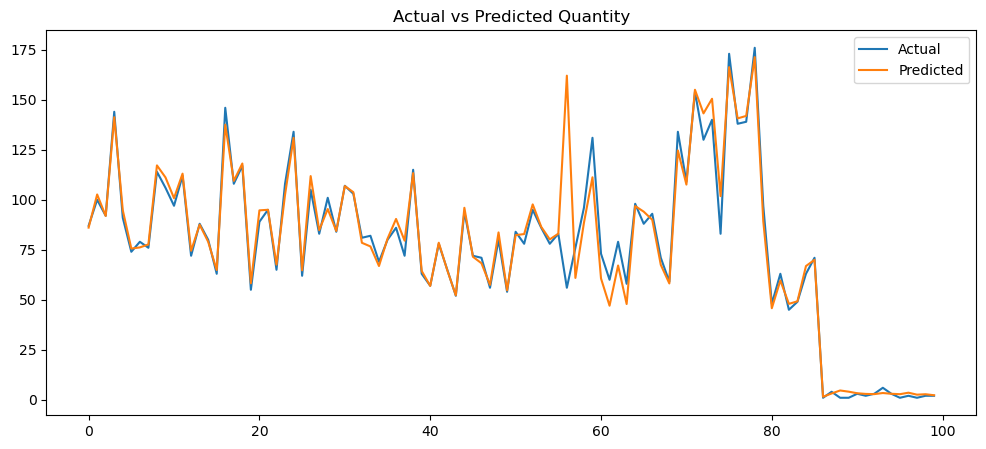

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(preds[:100], label="Predicted")
plt.title("Actual vs Predicted Quantity")
plt.legend()
plt.show()

#### Feature importance

In [28]:
importance = pd.DataFrame({
    "feature": ml_features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
10,lag_1,0.398097
14,rolling_mean_7,0.288648
11,lag_7,0.087150
22,product_total,0.041762
21,store_total,0.032816
12,lag_14,0.026263
15,rolling_mean_28,0.022382
24,product_rolling_7,0.016430
23,store_rolling_7,0.009842
25,momentum_7,0.008845


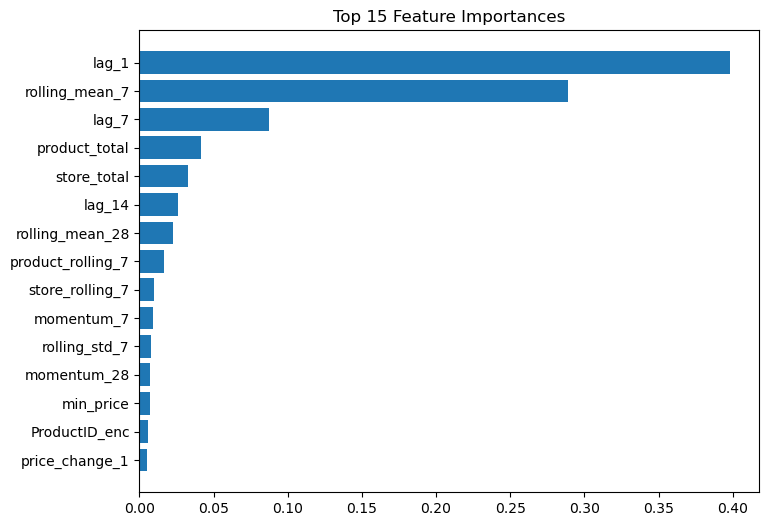

In [29]:
top_imp = importance.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top 15 Feature Importances")
plt.show()

#### Save model artifacts

In [31]:
os.makedirs("../artifacts", exist_ok=True)

joblib.dump(model, "../artifacts/xgb_model.pkl")
joblib.dump(store_encoder, "../artifacts/store_encoder.pkl")
joblib.dump(product_encoder, "../artifacts/product_encoder.pkl")

with open("../artifacts/ml_features.json", "w") as f:
    json.dump(ml_features, f)

print("Artifacts saved.")

Artifacts saved.


#### Generate 365-day forecast

In [32]:
history = model_df.copy()
history["Date"] = pd.to_datetime(history["Date"])
history = history.sort_values(["StoreID", "ProductID", "Date"]).reset_index(drop=True)

last_date = history["Date"].max()
forecast_horizon = 365

results = []
series_keys = history[["StoreID", "ProductID"]].drop_duplicates()

In [33]:
for _, key_row in series_keys.iterrows():
    store_id = key_row["StoreID"]
    product_id = key_row["ProductID"]

    series_hist = history[
        (history["StoreID"] == store_id) &
        (history["ProductID"] == product_id)
    ].sort_values("Date").copy()

    if len(series_hist) < 30:
        continue

    qty_history = list(series_hist["Quantity"].values)
    price_history = list(series_hist["avg_price"].values)
    store_total_history = list(series_hist["store_total"].values)
    product_total_history = list(series_hist["product_total"].values)

    store_id_enc = store_encoder.transform([str(store_id)])[0]
    product_id_enc = product_encoder.transform([str(product_id)])[0]

    product_name = series_hist["ProductName"].iloc[-1] if "ProductName" in series_hist.columns else None

    for step in range(1, forecast_horizon + 1):
        future_date = last_date + timedelta(days=step)

        lag_1 = qty_history[-1] if len(qty_history) >= 1 else 0
        lag_7 = qty_history[-7] if len(qty_history) >= 7 else 0
        lag_14 = qty_history[-14] if len(qty_history) >= 14 else 0
        lag_28 = qty_history[-28] if len(qty_history) >= 28 else 0

        rolling_mean_7 = np.mean(qty_history[-7:]) if len(qty_history) >= 7 else np.mean(qty_history) if len(qty_history) > 0 else 0
        rolling_mean_28 = np.mean(qty_history[-28:]) if len(qty_history) >= 28 else np.mean(qty_history) if len(qty_history) > 0 else 0
        rolling_std_7 = np.std(qty_history[-7:]) if len(qty_history) >= 7 else np.std(qty_history) if len(qty_history) > 1 else 0
        rolling_std_28 = np.std(qty_history[-28:]) if len(qty_history) >= 28 else np.std(qty_history) if len(qty_history) > 1 else 0

        last_price = price_history[-1] if len(price_history) > 0 else 0
        price_7 = price_history[-7] if len(price_history) >= 7 else last_price
        price_28 = price_history[-28] if len(price_history) >= 28 else last_price

        price_change_1 = ((last_price - price_history[-2]) / price_history[-2]) if len(price_history) >= 2 and price_history[-2] != 0 else 0
        price_change_7 = ((last_price - price_7) / price_7) if price_7 != 0 else 0
        price_change_28 = ((last_price - price_28) / price_28) if price_28 != 0 else 0

        store_total = store_total_history[-1] if len(store_total_history) > 0 else 0
        product_total = product_total_history[-1] if len(product_total_history) > 0 else 0

        store_rolling_7 = np.mean(store_total_history[-7:]) if len(store_total_history) >= 7 else np.mean(store_total_history) if len(store_total_history) > 0 else 0
        product_rolling_7 = np.mean(product_total_history[-7:]) if len(product_total_history) >= 7 else np.mean(product_total_history) if len(product_total_history) > 0 else 0

        momentum_7 = lag_1 - lag_7
        momentum_28 = lag_1 - lag_28

        future_row_dict = {
            "StoreID_enc": store_id_enc,
            "ProductID_enc": product_id_enc,
            "year": future_date.year,
            "month": future_date.month,
            "day_of_week": future_date.isoweekday() % 7 + 1,
            "week_of_year": int(future_date.isocalendar().week),
            "is_weekend": 1 if future_date.weekday() >= 5 else 0,
            "avg_price": last_price,
            "max_price": last_price,
            "min_price": last_price,
            "lag_1": lag_1,
            "lag_7": lag_7,
            "lag_14": lag_14,
            "lag_28": lag_28,
            "rolling_mean_7": rolling_mean_7,
            "rolling_mean_28": rolling_mean_28,
            "rolling_std_7": rolling_std_7,
            "rolling_std_28": rolling_std_28,
            "price_change_1": price_change_1,
            "price_change_7": price_change_7,
            "price_change_28": price_change_28,
            "store_total": store_total,
            "product_total": product_total,
            "store_rolling_7": store_rolling_7,
            "product_rolling_7": product_rolling_7,
            "momentum_7": momentum_7,
            "momentum_28": momentum_28,
        }

        future_row = pd.DataFrame([future_row_dict])[ml_features].apply(pd.to_numeric, errors="coerce").fillna(0)

        pred_log = model.predict(future_row)[0]
        pred_qty = np.expm1(pred_log)
        pred_qty = max(0, pred_qty)

        qty_history.append(pred_qty)
        price_history.append(last_price)
        store_total_history.append(store_total)
        product_total_history.append(product_total)

        results.append({
            "StoreID": store_id,
            "ProductID": product_id,
            "ProductName": product_name,
            "Date": future_date,
            "ForecastQuantity": pred_qty,
            "AssumedPrice": last_price,
            "ForecastRevenue": pred_qty * last_price
        })

#### Create forecast output

In [34]:
forecast_pd = pd.DataFrame(results)
forecast_pd.head()

,StoreID,ProductID,ProductName,Date,ForecastQuantity,AssumedPrice,ForecastRevenue
0,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2026-01-01,70.029709,5.259259,368.304395
1,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2026-01-02,70.880219,5.259259,372.777445
2,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2026-01-03,71.098709,5.259259,373.926544
3,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2026-01-04,70.619133,5.259259,371.404329
4,024a0bfc4484,16a562fb5931,Pasta and Beans and Tandoori Masala,2026-01-05,68.537064,5.259259,360.454186


#### Outputs for Streamlit

In [36]:
historical_output = df.toPandas().copy()
historical_output["Date"] = pd.to_datetime(historical_output["Date"])
historical_output["Revenue"] = historical_output["Quantity"] * historical_output["Price"]
historical_output.to_parquet("../artifacts/historical.parquet", index=False)

In [37]:
forecast_pd["Date"] = pd.to_datetime(forecast_pd["Date"])
forecast_pd.to_parquet("../artifacts/forecast_next_365_days.parquet", index=False)

#### Metrics

In [38]:
metrics = {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "WAPE": float(wape),
    "cutoff_date": str(cutoff_date)
}

with open("../artifacts/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

#### Feature Importance

In [39]:
importance.to_csv("../artifacts/feature_importance.csv", index=False)

In [40]:
print("Historical total quantity:", historical_output["Quantity"].sum())
print("Forecast total quantity:", forecast_pd["ForecastQuantity"].sum())

print("Historical avg daily quantity:",
      historical_output.groupby("Date")["Quantity"].sum().mean())

print("Forecast avg daily quantity:",
      forecast_pd.groupby("Date")["ForecastQuantity"].sum().mean())

Historical total quantity: 5872824.799999999
Forecast total quantity: 4172900.8
Historical avg daily quantity: 11359.429013539651
Forecast avg daily quantity: 11432.606


#### Example Forecast

In [41]:
def plot_forecast(history_df, forecast_df, store_id, product_id, history_days=120, forecast_days=90):
    hist = history_df[
        (history_df["StoreID"] == store_id) &
        (history_df["ProductID"] == product_id)
    ].copy()

    fcst = forecast_df[
        (forecast_df["StoreID"] == store_id) &
        (forecast_df["ProductID"] == product_id)
    ].copy()

    hist = hist.sort_values("Date").tail(history_days)
    fcst = fcst.sort_values("Date").head(forecast_days)

    plt.figure(figsize=(14, 5))
    plt.plot(hist["Date"], hist["Quantity"], label="Historical Quantity")
    plt.plot(fcst["Date"], fcst["ForecastQuantity"], label="Forecast Quantity")
    plt.title(f"StoreID={store_id}, ProductID={product_id}")
    plt.xlabel("Date")
    plt.ylabel("Quantity")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

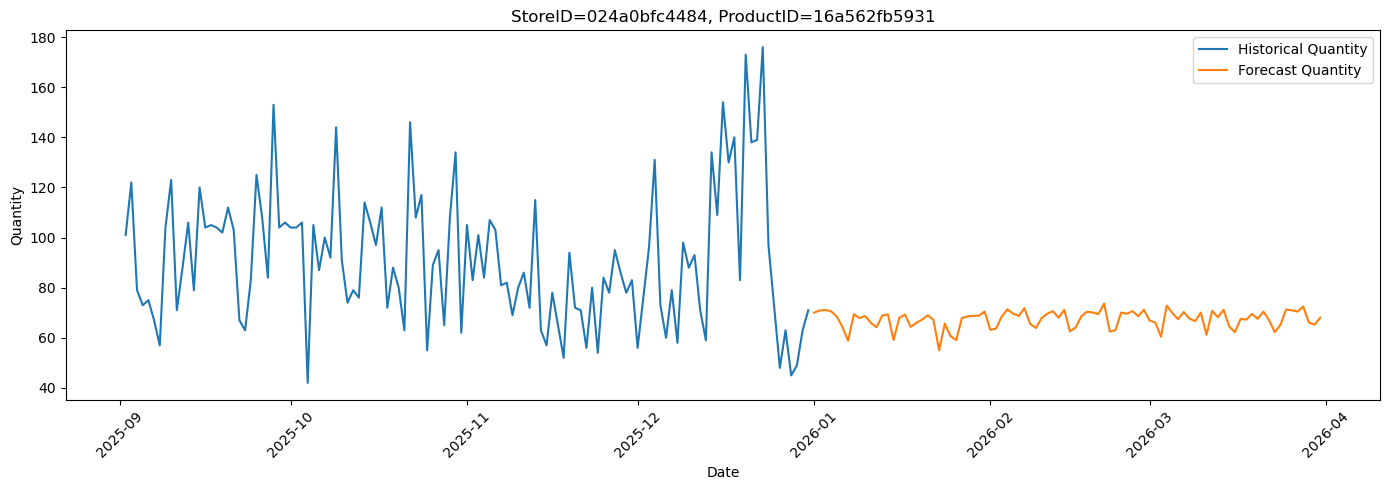

In [42]:
example_store = forecast_pd["StoreID"].iloc[0]
example_product = forecast_pd["ProductID"].iloc[0]

plot_forecast(model_df, forecast_pd, example_store, example_product)

In [43]:
model_df["Quantity"].mean()

105.46700668055453